In [142]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

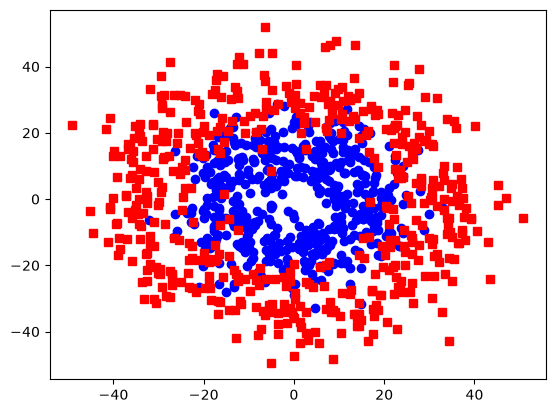

In [143]:
N = 512
space = np.linspace(0, 2*np.pi, N)
a_blur = 6
a_r = 16
b_blur = 8
b_r = 32

A = [a_r * np.cos(space) + np.random.randn(N) * a_blur, a_r * np.sin(space) + np.random.randn(N) * a_blur]
B = [b_r * np.cos(space) + np.random.randn(N) * b_blur, b_r * np.sin(space) + np.random.randn(N) * b_blur]
data = torch.tensor(np.hstack((A, B)).T).float()
labels = torch.tensor(np.vstack((np.zeros((N, 1)), np.ones((N, 1))))).float()

plt.plot(data[np.where(labels == 0)[0], 0], data[np.where(labels == 0)[0], 1], 'bo')
plt.plot(data[np.where(labels == 1)[0], 0], data[np.where(labels == 1)[0], 1], 'rs')
plt.show()

In [144]:
class RegModel(nn.Module):
    def __init__(self, n_layers, n_units):
        super().__init__()

        self.n_layers = n_layers
        self.layers = nn.ModuleDict()

        self.layers['input'] = nn.Linear(2, n_units)
        for i in range(n_layers):
            self.layers[f'hidden{i}'] = nn.Linear(n_units, n_units)
        self.layers['output'] = nn.Linear(n_units, 1)

    def forward(self, x):
        x = self.layers['input'](x)
        x = F.relu(x)

        for i in range(self.n_layers):
            x = self.layers[f'hidden{i}'](x)
            x = F.relu(x)

        x = self.layers['output'](x)
        return x

    def fit(self, data, labels, training_epochs, train_size, batch_size):
        loss_func = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.SGD(self.parameters(), lr=0.02)
        train_data, test_data, train_labels, test_labels = train_test_split(data, labels, train_size=train_size)
        train_ldr = DataLoader(TensorDataset(torch.tensor(train_data), torch.tensor(train_labels)), batch_size)

        train_losses = torch.zeros(training_epochs)
        train_accuracies = torch.zeros(training_epochs)
        test_accuracies = torch.zeros(training_epochs)

        for epoch in range(training_epochs):
            batch_losses = torch.zeros(len(train_ldr))
            for i, batch in enumerate(train_ldr):
                y_hat = self.forward(batch[0])

                loss = loss_func(y_hat, batch[1])
                batch_losses[i] = loss

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            train_losses[epoch] = torch.mean(batch_losses)
            train_accuracies[epoch] = torch.mean(((F.sigmoid(self.forward(train_data)) > 0.5) == train_labels).float())
            test_accuracies[epoch] = torch.mean(((F.sigmoid(self.forward(test_data)) > 0.5) == test_labels).float())

        return train_losses, train_accuracies, test_accuracies

/var/folders/y7/t_kyj9cd5md46_6j9s4r2sl80000gp/T/ipykernel_57177/3494255794.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ldr = DataLoader(TensorDataset(torch.tensor(train_data), torch.tensor(train_labels)), batch_size)


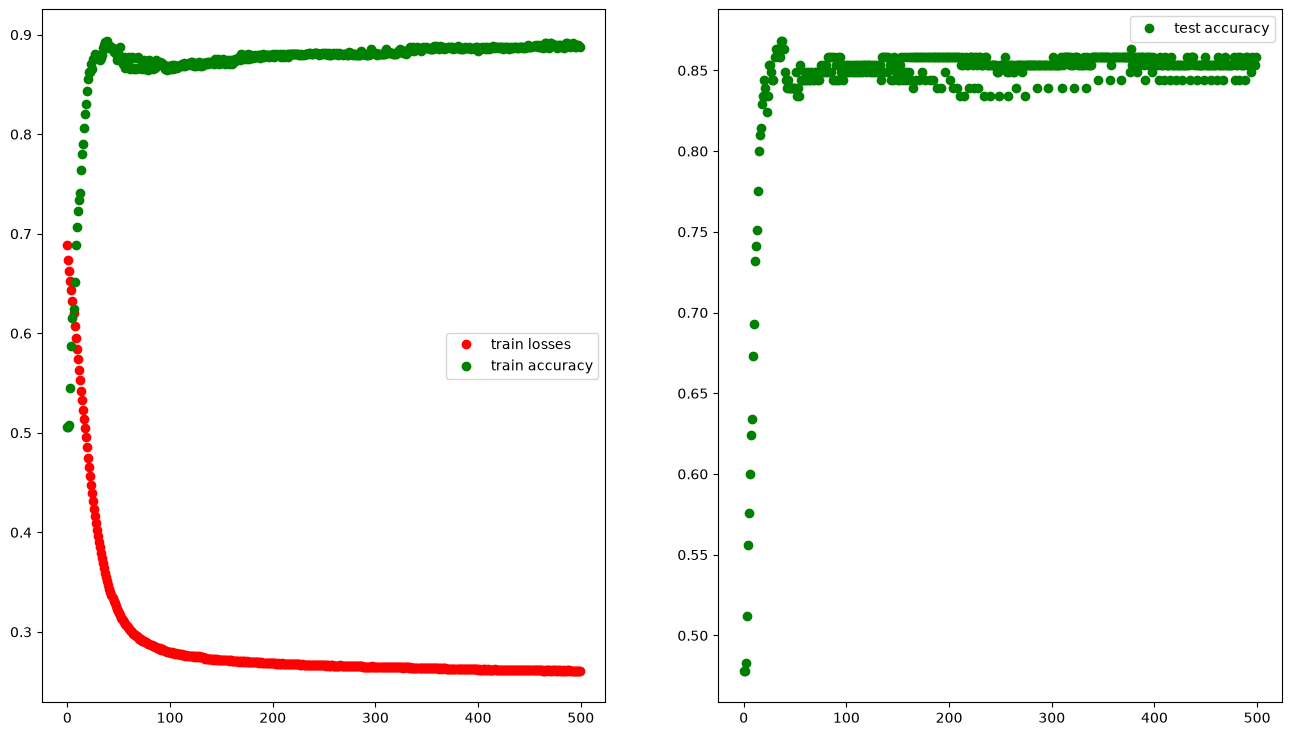

In [145]:
reg_model = RegModel(2, 8)
train_losses, train_accuracies, test_accuracies = reg_model.fit(data, labels, 500, 0.8, 32)

fig, ax = plt.subplots(1, 2, figsize=(16, 9))
ax[0].plot(train_losses.detach(), 'ro', label='train losses')
ax[0].plot(train_accuracies.detach(), 'go', label='train accuracy')
ax[0].legend()
ax[1].plot(test_accuracies.detach(), 'go', label='test accuracy')
ax[1].legend()
plt.show()

In [146]:
class DropoutModel(nn.Module):
    def __init__(self, n_layers, n_units, dropout_rate):
        super().__init__()

        self.n_layers = n_layers
        self.layers = nn.ModuleDict()

        self.layers['input'] = nn.Linear(2, n_units)
        for i in range(n_layers):
            self.layers[f'hidden{i}'] = nn.Linear(n_units, n_units)
        self.layers['output'] = nn.Linear(n_units, 1)

        self.dropout_rate = dropout_rate

    def forward(self, x):
        x = self.layers['input'](x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate)

        for i in range(self.n_layers):
            x = self.layers[f'hidden{i}'](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout_rate)

        x = self.layers['output'](x)
        return x

    def fit(self, data, labels, training_epochs, train_size, batch_size):
        loss_func = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.SGD(self.parameters(), lr=0.02)
        train_data, test_data, train_labels, test_labels = train_test_split(data, labels, train_size=train_size)
        train_ldr = DataLoader(TensorDataset(torch.tensor(train_data), torch.tensor(train_labels)), batch_size)

        train_losses = torch.zeros(training_epochs)
        train_accuracies = torch.zeros(training_epochs)
        test_accuracies = torch.zeros(training_epochs)

        for epoch in range(training_epochs):
            self.train()
            batch_losses = torch.zeros(len(train_ldr))
            for i, batch in enumerate(train_ldr):
                y_hat = self.forward(batch[0])

                loss = loss_func(y_hat, batch[1])
                batch_losses[i] = loss

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            self.eval()
            train_losses[epoch] = torch.mean(batch_losses)
            train_accuracies[epoch] = torch.mean(((F.sigmoid(self.forward(train_data)) > 0.5) == train_labels).float())
            test_accuracies[epoch] = torch.mean(((F.sigmoid(self.forward(test_data)) > 0.5) == test_labels).float())

        return train_losses, train_accuracies, test_accuracies

/var/folders/y7/t_kyj9cd5md46_6j9s4r2sl80000gp/T/ipykernel_57177/1760796096.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ldr = DataLoader(TensorDataset(torch.tensor(train_data), torch.tensor(train_labels)), batch_size)


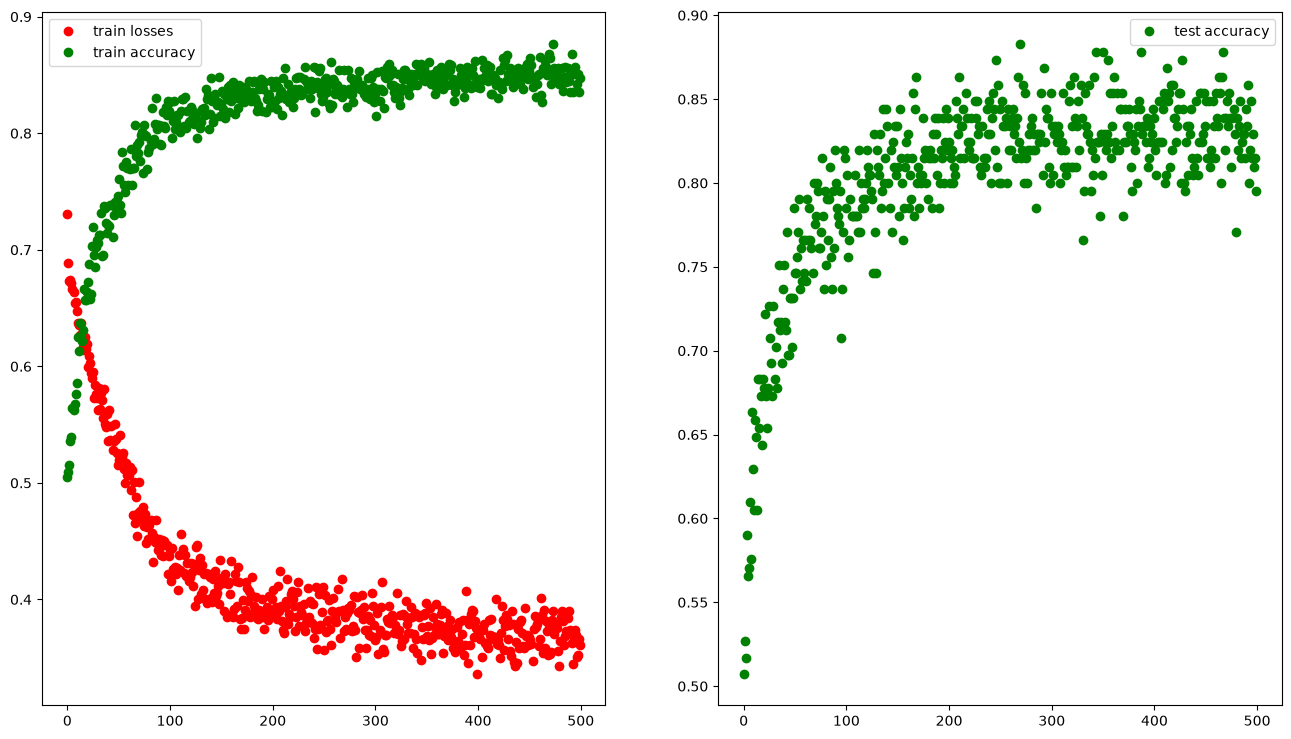

In [147]:
dropout_model = DropoutModel(2, 8, 0.2)
train_losses, train_accuracies, test_accuracies = dropout_model.fit(data, labels, 500, 0.8, 32)

fig, ax = plt.subplots(1, 2, figsize=(16, 9))
ax[0].plot(train_losses.detach(), 'ro', label='train losses')
ax[0].plot(train_accuracies.detach(), 'go', label='train accuracy')
ax[0].legend()
ax[1].plot(test_accuracies.detach(), 'go', label='test accuracy')
ax[1].legend()
plt.show()

In [148]:
class L2Model(nn.Module):
    def __init__(self, n_layers, n_units):
        super().__init__()

        self.n_layers = n_layers
        self.layers = nn.ModuleDict()

        self.layers['input'] = nn.Linear(2, n_units)
        for i in range(n_layers):
            self.layers[f'hidden{i}'] = nn.Linear(n_units, n_units)
        self.layers['output'] = nn.Linear(n_units, 1)

    def forward(self, x):
        x = self.layers['input'](x)
        x = F.relu(x)

        for i in range(self.n_layers):
            x = self.layers[f'hidden{i}'](x)
            x = F.relu(x)

        x = self.layers['output'](x)
        return x

    def fit(self, data, labels, training_epochs, train_size, batch_size, l2lambda):
        loss_func = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.SGD(self.parameters(), lr=0.02, weight_decay=l2lambda)
        train_data, test_data, train_labels, test_labels = train_test_split(data, labels, train_size=train_size)
        train_ldr = DataLoader(TensorDataset(torch.tensor(train_data), torch.tensor(train_labels)), batch_size)

        train_losses = torch.zeros(training_epochs)
        train_accuracies = torch.zeros(training_epochs)
        test_accuracies = torch.zeros(training_epochs)

        for epoch in range(training_epochs):
            self.train()
            batch_losses = torch.zeros(len(train_ldr))
            for i, batch in enumerate(train_ldr):
                y_hat = self.forward(batch[0])

                loss = loss_func(y_hat, batch[1])
                batch_losses[i] = loss

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            self.eval()
            train_losses[epoch] = torch.mean(batch_losses)
            train_accuracies[epoch] = torch.mean(((F.sigmoid(self.forward(train_data)) > 0.5) == train_labels).float())
            test_accuracies[epoch] = torch.mean(((F.sigmoid(self.forward(test_data)) > 0.5) == test_labels).float())

        return train_losses, train_accuracies, test_accuracies

/var/folders/y7/t_kyj9cd5md46_6j9s4r2sl80000gp/T/ipykernel_57177/58819507.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ldr = DataLoader(TensorDataset(torch.tensor(train_data), torch.tensor(train_labels)), batch_size)


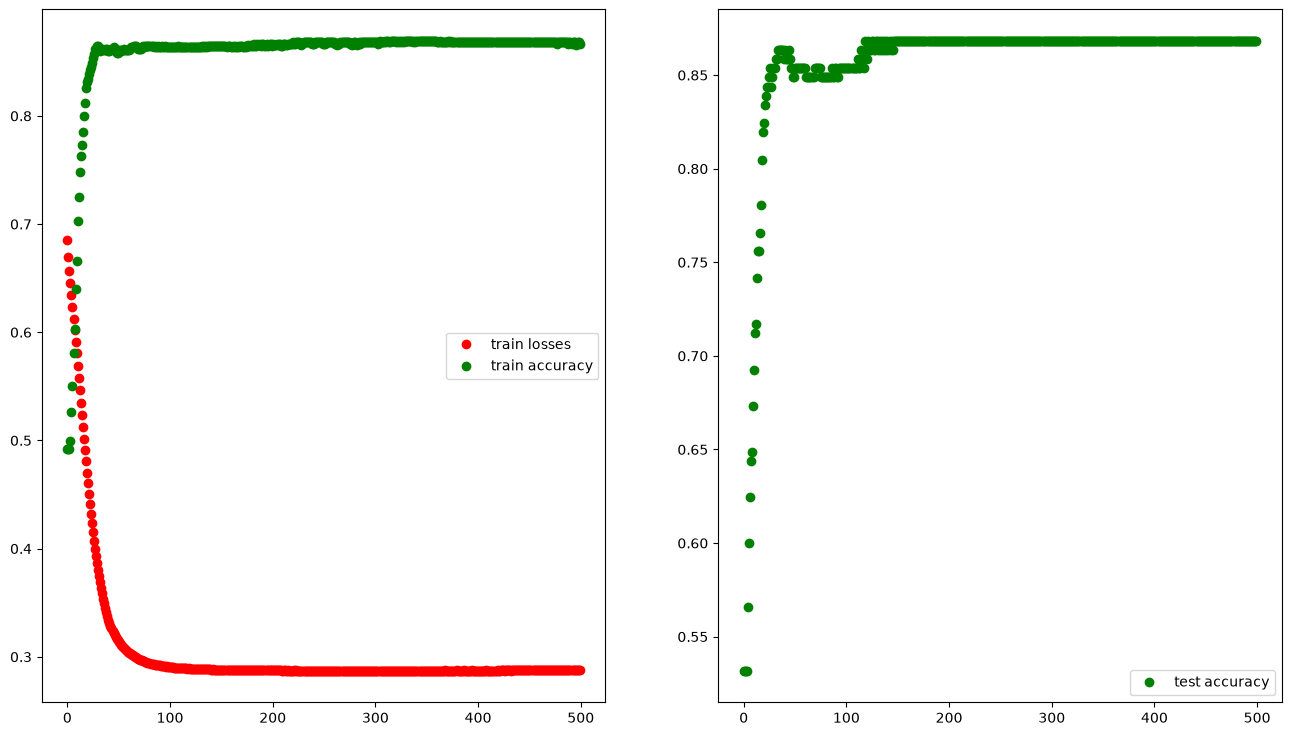

In [149]:
l2_model = L2Model(2, 8)
train_losses, train_accuracies, test_accuracies = l2_model.fit(data, labels, 500, 0.8, 32, 0.01)

fig, ax = plt.subplots(1, 2, figsize=(16, 9))
ax[0].plot(train_losses.detach(), 'ro', label='train losses')
ax[0].plot(train_accuracies.detach(), 'go', label='train accuracy')
ax[0].legend()
ax[1].plot(test_accuracies.detach(), 'go', label='test accuracy')
ax[1].legend()
plt.show()

In [150]:
class L1Model(nn.Module):
    def __init__(self, n_layers, n_units):
        super().__init__()

        self.n_layers = n_layers
        self.layers = nn.ModuleDict()

        self.layers['input'] = nn.Linear(2, n_units)
        for i in range(n_layers):
            self.layers[f'hidden{i}'] = nn.Linear(n_units, n_units)
        self.layers['output'] = nn.Linear(n_units, 1)

    def forward(self, x):
        x = self.layers['input'](x)
        x = F.relu(x)

        for i in range(self.n_layers):
            x = self.layers[f'hidden{i}'](x)
            x = F.relu(x)

        x = self.layers['output'](x)
        return x

    def fit(self, data, labels, training_epochs, train_size, batch_size, l1lambda):
        loss_func = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.SGD(self.parameters(), lr=0.02)
        train_data, test_data, train_labels, test_labels = train_test_split(data, labels, train_size=train_size)
        train_ldr = DataLoader(TensorDataset(torch.tensor(train_data), torch.tensor(train_labels)), batch_size)

        train_losses = torch.zeros(training_epochs)
        train_accuracies = torch.zeros(training_epochs)
        test_accuracies = torch.zeros(training_epochs)

        for epoch in range(training_epochs):
            self.train()
            batch_losses = torch.zeros(len(train_ldr))
            for i, batch in enumerate(train_ldr):
                y_hat = self.forward(batch[0])

                loss = loss_func(y_hat, batch[1])
                l1_penalization = torch.tensor(0.0, requires_grad=True)
                for p in self.parameters():
                    l1_penalization = l1_penalization + p.abs().sum()
                l1_penalization = l1_penalization * l1lambda
                loss = loss + l1_penalization

                batch_losses[i] = loss

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            self.eval()
            train_losses[epoch] = torch.mean(batch_losses)
            train_accuracies[epoch] = torch.mean(((F.sigmoid(self.forward(train_data)) > 0.5) == train_labels).float())
            test_accuracies[epoch] = torch.mean(((F.sigmoid(self.forward(test_data)) > 0.5) == test_labels).float())

        return train_losses, train_accuracies, test_accuracies

/var/folders/y7/t_kyj9cd5md46_6j9s4r2sl80000gp/T/ipykernel_57177/1521517253.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ldr = DataLoader(TensorDataset(torch.tensor(train_data), torch.tensor(train_labels)), batch_size)


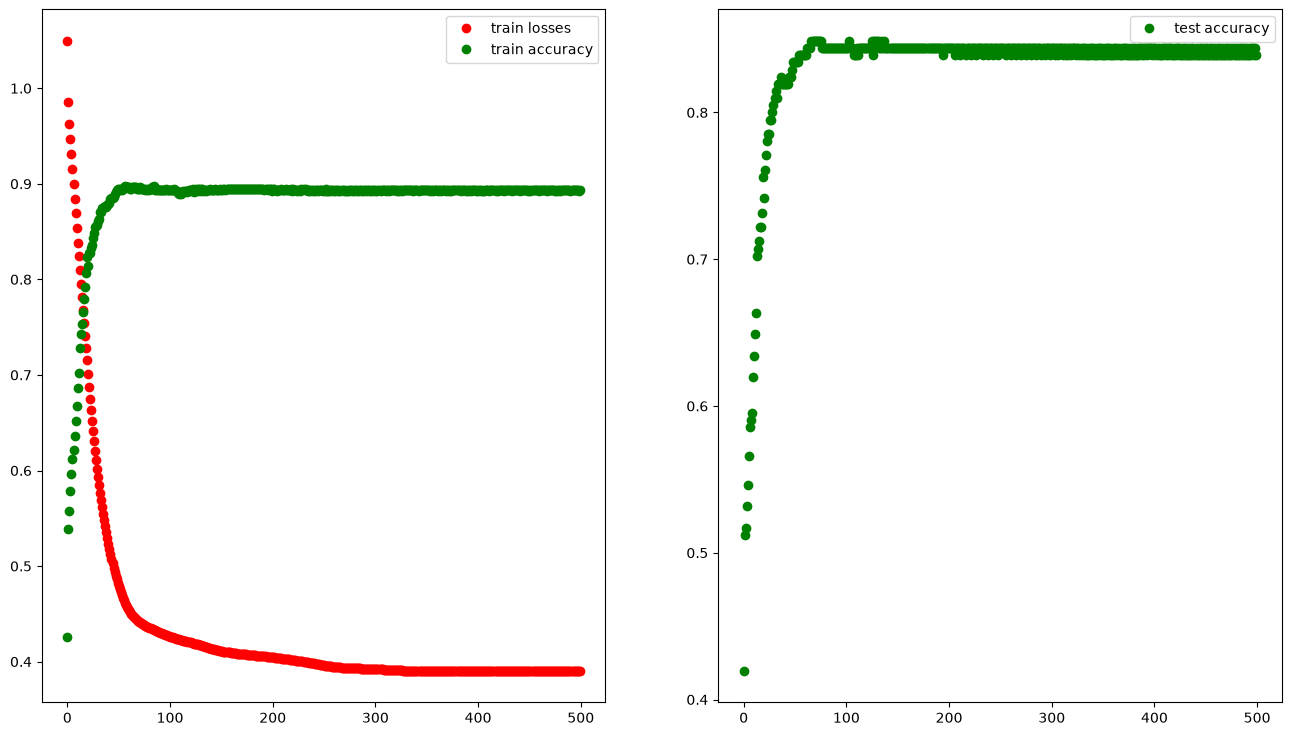

In [151]:
l1_model = L1Model(2, 8)
train_losses, train_accuracies, test_accuracies = l1_model.fit(data, labels, 500, 0.8, 32, 0.01)

fig, ax = plt.subplots(1, 2, figsize=(16, 9))
ax[0].plot(train_losses.detach(), 'ro', label='train losses')
ax[0].plot(train_accuracies.detach(), 'go', label='train accuracy')
ax[0].legend()
ax[1].plot(test_accuracies.detach(), 'go', label='test accuracy')
ax[1].legend()
plt.show()